In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def inicializar_ambiente(linhas, colunas, num_itens=None, densidade=0.1):
    """
    Cria a matriz do ambiente com itens (1) e espaços vazios (0).
    Distribuição: Aleatória uniforme.
    """
    if num_itens is not None:
        total = linhas * colunas
        grid = np.zeros(total, dtype=int)
        idx = np.random.choice(total, size=num_itens, replace=False)
        grid[idx] = 1
        return grid.reshape((linhas, colunas))

    # Usando np.random.choice para garantir a distribuição uniforme baseada em probabilidade
    grid = np.random.choice(
        [0, 1], 
        size=(linhas, colunas), 
        p=[1 - densidade, densidade]
    )
    return grid

In [3]:
def visualizar_ambiente(grid, titulo):
    """
    Gera um gráfico do ambiente.
    Preto (1) representa os itens, Branco (0) representa o vazio.
    """
    plt.imshow(grid, cmap='binary', interpolation='nearest')
    plt.title(f"{titulo} (Densidade Real: {np.mean(grid)*100:.1f}%)")
    plt.xlabel("X (Células)")
    plt.ylabel("Y (Células)")
    plt.colorbar(label='0: Vazio | 1: Item')
    plt.savefig('ambiente_'+titulo+'.png')
    print("Gráfico gerado: ambiente_inicial.png")

In [4]:
# Configurações
LARGURA, ALTURA = 10, 10
DENSIDADE_ITENS = 0.1  # 10%

Gráfico gerado: ambiente_inicial.png


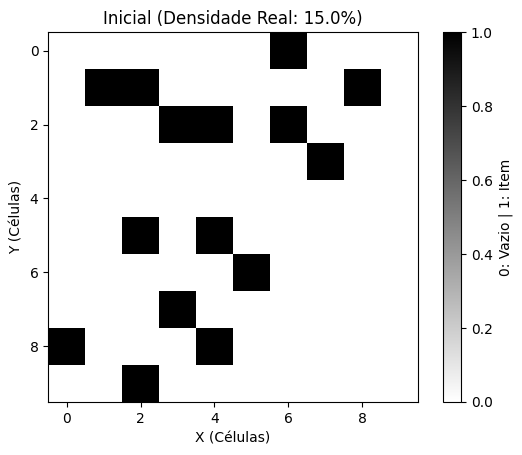

In [5]:
# Execução
ambiente = inicializar_ambiente(LARGURA, ALTURA, densidade=DENSIDADE_ITENS)
visualizar_ambiente(ambiente, "Inicial")

In [6]:
# Exportando para inspeção (conforme diretrizes)
pd.DataFrame(ambiente).to_csv('ambiente_inicial.csv', index=False)

In [7]:
import random
import numpy as np

In [8]:
class Ant:
    def __init__(self, x, y, r=1):
        self.x = x
        self.y = y
        self.r = r
        self.carregando = False

    def move(self, max_x, max_y):
        """Movimento aleatório com bordas toroidais (infinitas)."""
        direcoes = [(0, 1), (0, -1), (1, 0), (-1, 0)]
        dx, dy = random.choice(direcoes)
        
        # Bordas infinitas: sair de um lado reaparece no outro
        nova_x = (self.x + dx) % max_x
        nova_y = (self.y + dy) % max_y
        
        self.x, self.y = nova_x, nova_y

    def get_density(self, matrix):
        """Calcula f = n / área no raio r usando vizinhança toroidal."""
        linhas, colunas = matrix.shape
        n = 0
        total_celulas = 0
        
        # Define os limites do quadrado (vizinhança de Moore)
        for i in range(self.x - self.r, self.x + self.r + 1):
            for j in range(self.y - self.r, self.y + self.r + 1):
                i_wrap = i % linhas
                j_wrap = j % colunas
                n += matrix[i_wrap, j_wrap]
                total_celulas += 1
        
        # Densidade f (entre 0 e 1)
        return n / total_celulas if total_celulas > 0 else 0

    def decidir_acao(self, matrix):
        f = self.get_density(matrix)
        item_na_celula = matrix[self.x, self.y]

        if not self.carregando:
            # Tentar PEGAR
            if item_na_celula == 1:
                p_pegar = (1 - f) ** 2
                if random.random() < p_pegar:
                    matrix[self.x, self.y] = 0  # Remove da matriz
                    self.carregando = True
                    return "pegou"
        
        else:
            # Tentar LARGAR
            if item_na_celula == 0:
                p_largar = f ** 2
                if random.random() < p_largar:
                    matrix[self.x, self.y] = 1  # Devolve à matriz
                    self.carregando = False
                    return "largou"
        
        return "nada"

Iniciando simulação...
Gráfico gerado: ambiente_inicial.png
Simulação concluída após 100000 iterações
Gráfico gerado: ambiente_inicial.png


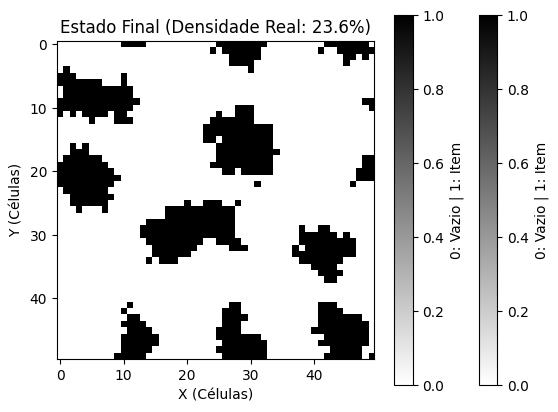

In [9]:
# --- Configurações Finais ---
NUM_FORMIGAS = 15
NUM_ITERACOES = 100_000
LARGURA, ALTURA = 50, 50
NUM_ITENS = 600

# 1. Inicializar Ambiente e Formigas
ambiente = inicializar_ambiente(LARGURA, ALTURA, num_itens=NUM_ITENS)
formigas = [Ant(random.randint(0, LARGURA-1), random.randint(0, ALTURA-1)) for _ in range(NUM_FORMIGAS)]

print("Iniciando simulação...")
visualizar_ambiente(ambiente, titulo="Estado Inicial")

# 2. Loop Principal (iterações fixas)
for iteracao in range(NUM_ITERACOES):
    for ant in formigas:
        ant.move(LARGURA, ALTURA)
        ant.decidir_acao(ambiente)

# 3. Resultado Final
print("Simulação concluída após", NUM_ITERACOES, "iterações")
visualizar_ambiente(ambiente, titulo="Estado Final")